<a href="https://colab.research.google.com/github/dom-dang/7.C01/blob/main/7_C01_PSET6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <center> Problem Set 6 <center>
<center> 3.C01/3.C51, 7.C01/7.C51, 10.C01/10.C51, 20.C01/20.C51<center>
<center> Due: Monday, May 11, 2026 at 3:00 PM ET. <center>



<b>Name:</b> Dominique Dang

<b>Kerberos id:</b> ddang

### Learning Objective
The objective of this problem set is to learn how to leverage foundation models, specifically Protein Language Models (pLMs) like ESM2, for downstream predictive tasks. You will generate and analyze protein embeddings, train and evaluate a Multi-Layer Perceptron (MLP) for protein function prediction using Gene Ontology (GO) terms, and compare this against an MLP trained on naive one-hot encoded sequences. Finally, you will use ESMFold to predict a protein's 3D structure from its sequence.


### Instructions
- This problem set has two modeling tasks with several sub-questions. This problem set is only for undergraduates.

- To get started, make your own copy of this notebook template in Colab (e.g., "Save a copy in Drive") before editing.

    - Important: this problem set requires a GPU. In Google Colab go to `Edit -> Notebook settings` and set the `Hardware accelerator` to a GPU before running the notebook (changing the runtime resets the notebook). See the GPU section below for additional help.

- Collaboration is encouraged and AI tools are permitted, but submitting work that is not your own is plagiarism. Any collaboration or assistance from others or from an LLM (including utilities integrated in Colab) must be described at the end of your submission.

- Additional notes about how to use this template:
    - Put your code in the code blocks flagged with `############# Code ##########`.

    -  Numerical answers yielded from running the code should be included in an Answer Block (see next cell).

    - We have provided print statements where numerical answers are expected.

    -  Your answer should be contained in a variable which you defined either in the Answer Block or the Code Block.

    - When a qualitative answer is expected, place those comments as Markdown/Text cells; when asked for within Code blocks, you can write answer as code comments by placing a # before your answer.

- Submission: upload your completed `pset6.ipynb` to Gradescope. Ensure the notebook runs without error and includes all necessary code, plots, and outputs. Comments are encouraged; place conceptual answers in Markdown/Text cells.


### Background (optional)
Protein Language Models (pLMs), including Meta's [ESMFold](https://www.science.org/doi/10.1126/science.ade2574), are used to generate protein structures given an input sequence. ESMFold stems from the ESM2 model, which generates embeddings for protein sequences, leveraging the transformer architecture (similar to the Bidirectional Encoder Representations from Transformers (BERT) model in the context of Natural Language Processing (NLP)).

ESM2 was trained using a masked language modeling objective, where a given position in the input amino acid sequence is masked and the model has to predict the most likely amino acid at that position. This is repeated for every amino acid in the sequence. The transformer architecture helps capture long-range relationships between different parts of a protein sequence without explicitly providing any information about the protein's 3D structure. ESM2 was trained on approximately 65 million sequences from the [UniRef](https://www.uniprot.org/help/uniref) protein sequence database. The ESM2 model you will be working with in this PSET has around 3 billion parameters, 36 layers, 40 attention heads, and a hidden space dimension of 2560.

In part 1, you will leverage a pre-trained ESM2 model to generate embeddings for protein sequences and use them to train a small MLP to predict GO (Gene Ontology) terms for proteins. The GO knowledge base includes subontologies describing molecular functions of proteins, biological processes in which proteins are involved, and cellular components in which they are active. As expected, GO annotations can generally be propagated to homologous proteins. The [UniProtKB/Swiss-Prot database](https://www.uniprot.org/help/uniprotkb_sections) contains manually curated GO annotations for thousands of organisms and more than 550,000 proteins. You can learn more about GO terms [here](https://geneontology.org/).

Here, you will compare the performance of the MLP-ESM2 model with an MLP trained on one-hot encoded sequence data. The first task has been accomplished in recent publication [author et al.](#references). You can skim these papers if you would like, but that is not required to answer the questions in the PSET. All the required background is explained below.

In part 3, you will use ESMFold to predict the structure of one protein in the validation set.


# Install required packages & Mount Google Drive (0 points)

In [ ]:
!uv pip install fair-esm scikit-learn biopython matplotlib torch pandas tqdm transformers

Using Python 3.12.13 environment at: /usr
Checked 8 packages in 102ms


In [ ]:
import gdown
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np
from Bio import SeqIO
import seaborn as sns
import csv
import requests
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import umap
import matplotlib.pyplot as plt
import pickle
import os
from google.colab import drive
from collections import Counter
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_recall_fscore_support, precision_recall_curve
from tqdm import tqdm
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

# Get Training & Validation Data (0 points)

Run the cells below to extract the training and validation data.

In [ ]:
# Get validation data
file_id="1s0gr_uK7gs_jkc1dw-fZGc4XNQQ_51bT"
destination="valid_data.pkl"
!wget --no-check-certificate "https://drive.google.com/uc?export=download&id={file_id}" -O {destination}

--2026-05-08 21:15:54--  https://drive.google.com/uc?export=download&id=1s0gr_uK7gs_jkc1dw-fZGc4XNQQ_51bT
Resolving drive.google.com (drive.google.com)... 74.125.68.100, 74.125.68.138, 74.125.68.113, ...
Connecting to drive.google.com (drive.google.com)|74.125.68.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1s0gr_uK7gs_jkc1dw-fZGc4XNQQ_51bT&export=download [following]
--2026-05-08 21:15:54--  https://drive.usercontent.google.com/download?id=1s0gr_uK7gs_jkc1dw-fZGc4XNQQ_51bT&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.130.132, 2404:6800:4003:c02::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.130.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31750082 (30M) [application/octet-stream]
Saving to: ‘valid_data.pkl’

valid_data.pkl      100%[===================>]  30.28M  23.3MB/s    

In [ ]:
# Get training data
file_id = "1XFObkJHwns-BDmS7O4xmKc35iSwhinNk"
destination = "train_data.pkl"
gdown.download(id=file_id, output=destination, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1XFObkJHwns-BDmS7O4xmKc35iSwhinNk
From (redirected): https://drive.google.com/uc?id=1XFObkJHwns-BDmS7O4xmKc35iSwhinNk&confirm=t&uuid=495579fd-bbec-4904-bd11-4c2ccddc93a5
To: /content/train_data.pkl
100%|██████████| 653M/653M [00:17<00:00, 38.3MB/s]


'train_data.pkl'

In [ ]:
sampled_valid_data = pd.read_pickle('valid_data.pkl')
sampled_train_data = pd.read_pickle('train_data.pkl')

In [ ]:
# understanding the data
print("Train columns:", sampled_train_data.columns.tolist())
print("Valid columns:", sampled_valid_data.columns.tolist())
print("\nTrain head:")
print(sampled_train_data.head(2))
print("\nValid head:")
print(sampled_valid_data.head(2))

Train columns: ['index', 'proteins', 'accessions', 'genes', 'sequences', 'annotations', 'string_ids', 'orgs', 'interpros', 'exp_annotations', 'prop_annotations', 'cafa_target', 'esm', 'esm2']
Valid columns: ['index', 'proteins', 'accessions', 'genes', 'sequences', 'annotations', 'string_ids', 'orgs', 'interpros', 'exp_annotations', 'prop_annotations', 'cafa_target', 'esm', 'esm2']

Train head:
        index     proteins                       accessions   genes  \
57336  400055  RPA12_YEAST                  P32529; D6VWN4;  853526   
11761   65680  CHSTF_HUMAN  Q7LFX5; O60338; O60474; Q86VM4;   51363   

                                               sequences  \
57336  MSVVGSLIFCLDCGDLLENPNAVLGSNVECSQCKAIYPKSQFSNLK...   
11761  MRHCINCCIQLLPDGAHKQQVNCQGGPHHGHQACPTCKGENKILFR...   

                                             annotations  \
57336  [GO:0005736|IDA, GO:0003676|IEA, GO:0001054|ID...   
11761  [GO:0000139|TAS, GO:0016021|NAS, GO:0050656|ID...   

                   string_i

# Part 1: Leverage foundation models to predict protein structure and function
This part will require you to implement a deep neural network in PyTorch. If you need to, please go through the PyTorch tutorial [here](https://pytorch.org/tutorials/beginner/basics/intro.html) and the quickstart guide [here](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html). You'll want a GPU for this part - request one now.


## Problem 1.1: <font color="blue">(15 points)</font> Generate and Visualize ESM2 Embeddings

The output of layers in ESM models — so-called hidden states — can be converted into vector embeddings for amino acid sequences. These hidden states can be passed through a language modeling head to produce logits at each position, which are then transformed into probabilities using a softmax function. These probabilities can provide interpretable insights into the model’s understanding of protein sequences. Extract the ESM2 embeddings for both the training and validation datasets.



Project the ESM2 embeddings to 2 dimensions and visualize them using UMAP. <font color="blue">**(2.5 points)**</font>


-  What do you observe in terms of the information captured by the ESM2 embeddings for the training vs. validation sets? <font color="blue">**(2.5 points)**</font>

-  How might the observed patterns in the distribution of training vs. validation data affect out-of-distribution testing and generalization performance? <font color="blue">**(5 points)**</font>

-  What information about proteins can be useful when doing a train-test-validation split on sequence data? <font color="blue">**(5 points)**</font>


In [ ]:
## ANSWER ##
# ESM2 embeddings for the training vs. validation sets #
train_embeds = np.vstack(sampled_train_data['esm2'].apply(np.array).values)
valid_embeds = np.vstack(sampled_valid_data['esm2'].apply(np.array).values)

print(f"Train embeddings: {train_embeds.shape}")
print(f"Valid embeddings: {valid_embeds.shape}")


Train embeddings: (38533, 2560)
Valid embeddings: (1901, 2560)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


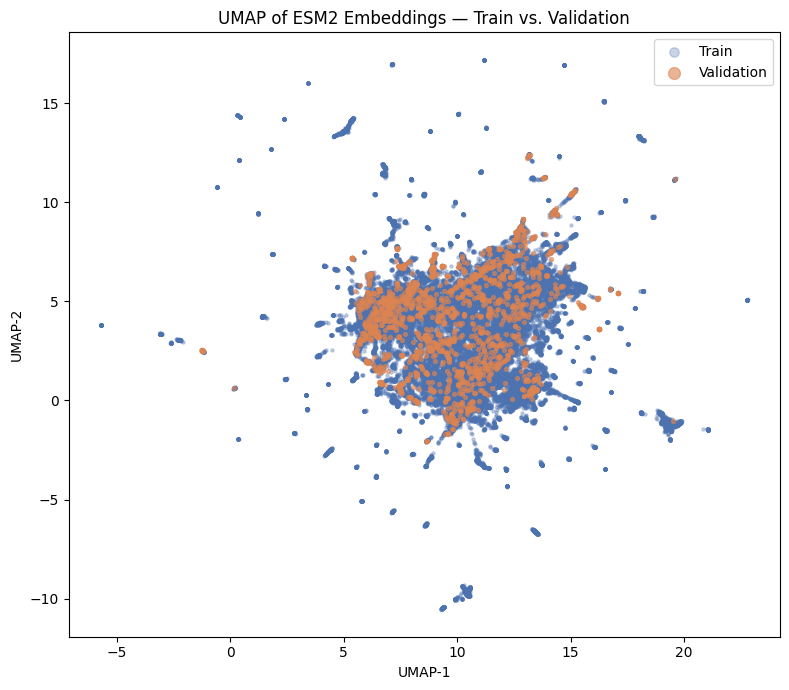

In [ ]:
######## CODE ##########
# Plot observed patterns in the distribution of training vs. validation data #
all_embeds = np.vstack([train_embeds, valid_embeds])

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
reduced = reducer.fit_transform(all_embeds)

train_2d = reduced[:len(train_embeds)]
valid_2d = reduced[len(train_embeds):]


plt.figure(figsize=(8, 7))
plt.scatter(train_2d[:, 0], train_2d[:, 1],
            c="#4C72B0", alpha=0.3, s=5, label="Train", rasterized=True)
plt.scatter(valid_2d[:, 0], valid_2d[:, 1],
            c="#DD8452", alpha=0.6, s=8, label="Validation", rasterized=True)
plt.title("UMAP of ESM2 Embeddings — Train vs. Validation")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig("umap_esm2.png", dpi=150, bbox_inches="tight")
plt.show()

######## CODE ##########

**Written Answers**
* The validation (orange) sits almost entirely within the dense core of the training distribution (blue). There is very high overlap in the embedding space. The training set has many points scattered in the periphery and isolated clusters that validation doesn't cover.
* The UMAP visualization shows that the validation set embeddings are almost entirely in the dense core of the training distribution, with very high overlap in the embedding space. This means the train/validation split is effectively random in embedding space, aka the model is being evaluated on proteins that are representationally similar to what it was trained on.
This is bad for assessing real-world generalization because when validation data closely mirrors the training distribution, reported validation metrics (precision, recall, F1) will systematically overestimate how well the model would perform on truly novel proteins.
* Some information about proteins that can be useful when doing a split is sequence identity clustering, protein family, or taxonomic origin.

## Problem 1.2: <font color="blue">(5 points)</font> Extract and binarize GO terms for training and validation data

Run the cells below to extract the GO terms (labels) for the training data, binarize the labels using `MultiLabelBinarizer`, and print the total number of unique GO terms in the dataset. Then, complete the preprocessing of the GO terms for the validation data using the `MultiLabelBinarizer.transform` function.

In [ ]:
if isinstance(sampled_train_data['annotations'].iloc[0], str):
    sampled_train_data['annotations'] = sampled_train_data['annotations'].apply(ast.literal_eval)

all_go_terms = sorted(set(term for go_list in sampled_train_data['annotations'] for term in go_list))
print(f"Number of unique GO terms is {len(all_go_terms)}")

mlb = MultiLabelBinarizer(classes=all_go_terms)
train_go_annotations = mlb.fit_transform(sampled_train_data['annotations'])
sampled_train_data['go_annotations'] = list(train_go_annotations)



# Filter out GO terms that are not in mlb class defined above for training set so train and validation set share labels
if isinstance(sampled_valid_data['annotations'].iloc[0], str):
    sampled_valid_data['annotations'] = sampled_valid_data['annotations'].apply(ast.literal_eval)

known_go_terms = set(mlb.classes_)

sampled_valid_data['filtered_annotations'] = sampled_valid_data['annotations'].apply(
    lambda go_list: [term for term in go_list if term in known_go_terms])

Number of unique GO terms is 81806


In [ ]:
######## CODE ##########
# complete the preprocessing of GO terms for the validation data here
valid_go_annotations = mlb.transform(sampled_valid_data['filtered_annotations'])
sampled_valid_data['go_annotations'] = list(valid_go_annotations)

print(f"Train labels shape: {train_go_annotations.shape}")
print(f"Valid labels shape: {valid_go_annotations.shape}")
######## CODE ##########

Train labels shape: (38533, 81806)
Valid labels shape: (1901, 81806)


## Problem 1.3: <font color="blue">(5 points)</font> Creating datasets for model training and validation

Complete the definition of the `ProteinDataset` class shown below. Both the ESM2 embeddings and labels should be converted to `torch.float32`. **(2.5 points)** Then, create datasets and dataloaders for the training and validation data using the `ProteinDataset` class you defined. Don't forget to shuffle the training dataloader but not the validation dataloader. **(2.5 points)**


In [ ]:
batch_size=32

class ProteinDataset(Dataset):
    def __init__(self, dataframe, go_annotations):

        ######## CODE ##########
        embeddings_np = np.array(dataframe['esm2'].tolist(), dtype=np.float32)
        self.embeddings = torch.from_numpy(embeddings_np)
        self.labels = torch.from_numpy(go_annotations.astype(np.float32))
        ######## CODE ##########

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [ ]:
######## CODE ##########
train_dataset = ProteinDataset(sampled_train_data, train_go_annotations)
valid_dataset = ProteinDataset(sampled_valid_data, valid_go_annotations)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

######## CODE ##########

## Problem 1.4: <font color="blue">(5 points)</font> Define the MLP

Complete the definition of the `ESM2MLP` class with the right dimensions.


In [ ]:
class MLPBlock(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
        self.layer_norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # First block
        if not hasattr(self, 'is_residual'):
            return F.relu(self.layer_norm(self.dropout(self.dense(x))))

        # Second block with residual connection
        identity = x
        x = self.dense(x)
        x = self.layer_norm(x)
        x = F.relu(x)
        return identity + x \


class ESM2MLP(nn.Module):
    def __init__(self, num_classes=len(mlb.classes_)):
        super().__init__()
        self.blocks = nn.Sequential(
            MLPBlock(train_embeds.shape[1], 1024),
            MLPBlock(1024, 1024),
            nn.Linear(1024, num_classes))
        self.blocks[1].is_residual = True

    def forward(self, x):
        return self.blocks(x)


#Instantiate model
model = ESM2MLP()

## Problem 1.5: Train and Evaluate Model

### 1.5.1 Train Model <font color="blue">(20 points)</font>

To train the model, start by setting up the Adam optimizer, with a learning rate `lr` of `1e-4`. (**5 points**)

Next, write your training loop using the provided `train_epoch()` function, and train the model for 10 epochs. This is a classification problem, so you will want to compute the binary cross-entropy loss using `nn.BCEWithLogitsLoss()`, which requires you to input classification probabilities and the ground truth labels from your data. (**10 points**)

Record the loss across epochs and plot the training loss across epochs. Comment briefly on the trend you observe. (**5 points**)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in tqdm(loader, desc="Training"):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ESM2MLP(
  (blocks): Sequential(
    (0): MLPBlock(
      (dense): Linear(in_features=2560, out_features=1024, bias=True)
      (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): MLPBlock(
      (dense): Linear(in_features=1024, out_features=1024, bias=True)
      (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): Linear(in_features=1024, out_features=81806, bias=True)
  )
)

In [ ]:
######## CODE ##########
# set up optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()


# Write training loop with train_epoch and record loss
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    loss = train_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(loss)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {loss:.4f}")

######## CODE ##########

Training: 100%|██████████| 1205/1205 [00:12<00:00, 98.16it/s]


Epoch 1/10 — Loss: 0.0120


Training: 100%|██████████| 1205/1205 [00:11<00:00, 100.97it/s]


Epoch 2/10 — Loss: 0.0016


Training: 100%|██████████| 1205/1205 [00:11<00:00, 100.73it/s]


...

Epoch 8/10 — Loss: 0.0010


Training: 100%|██████████| 1205/1205 [00:12<00:00, 100.14it/s]


Epoch 9/10 — Loss: 0.0009


Training: 100%|██████████| 1205/1205 [00:11<00:00, 100.98it/s]

Epoch 10/10 — Loss: 0.0008


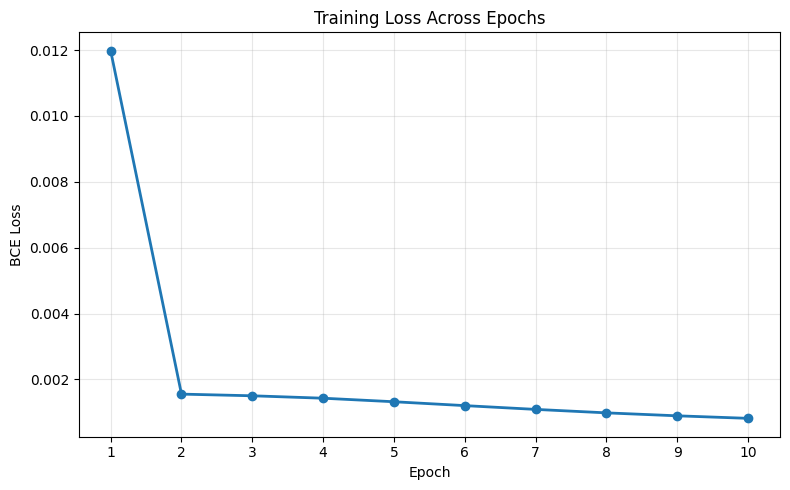

In [ ]:
######## CODE ##########
# Plot the training loss curve here
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linewidth=2)
plt.title("Training Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.xticks(range(1, num_epochs + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

######## CODE ##########

**The loss drops sharply after epoch 1 (from ~0.012 to ~0.0016), then continues to decrease gradually and plateaus near ~0.001 by epoch 10. The loss values are very small (on the order of 1e-3), which is expected for a highly sparse multi-label problem.**

### 1.5.2 Evaluate Model <font color="blue">(10 points)</font>


To evaluate the model, run the provided code cells and answer the following questions:


- Why do we need the sigmoid activation when looking at the predictions and converting them to probabilities? (**5 points**)

- Compute Precision, Recall, and F1-Score using the relevant scikit-learn function and comment on the values. Note the `'average'` argument. (**5 points**)

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(valid_dataset.embeddings.to(device))
    probabilities = torch.sigmoid(logits).cpu().numpy()

# Binary predictions with 0.5 threshold
binary_predictions = (probabilities >= 0.5).astype(np.float32)

# Get top 5 predicted indices per sample
top_hits = np.argsort(-probabilities, axis=1)[:, :5]

# Ensure top-5 predictions are always marked as 1
for i, indices in enumerate(top_hits):
    binary_predictions[i, indices] = 1

# Convert indices to GO term strings
top_go_terms = [[mlb.classes_[idx] for idx in row] for row in top_hits]
sampled_valid_data['top_5_predicted_go_terms'] = top_go_terms

In [ ]:
######## CODE ##########
# Compute precision, recall, and F1-score here
true_labels = valid_go_annotations  # ground truth binary matrix

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, binary_predictions, average='micro', zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
######## CODE ##########

Precision: 0.2389
Recall:    0.1154


**Written Answers:**
* nn.BCEWithLogitsLoss takes raw logits as input so it internally applies sigmoid during training for numerical stability. So the model's final nn.Linear layer outputs unbounded logits and not probabilities. To interpret predictions as probabilities in [0, 1] at evaluation time, we must explicitly apply torch.sigmoid(). Without it, thresholding at 0.5 would be meaningless since logits aren't bounded.

* Precision 0.24: when the model predicts a GO term, it's correct ~24% of the time. This means that most positive predictions are false alarms
* Recall 0.11: the model only captures ~11% of all true GO annotations so it misses the vast majority of correct labels
* F1 ~0.157 which poor overall
* these values make sense since the label space has thousands of GO terms but each protein only has a handful of true annotations (so the task is extremely sparse).

## Problem 1.6: <font color="blue">(30 points)</font> Compare with MLP trained on one-hot encoded sequences

We will compare the performance of an **MLP trained on ESM2 embeddings** with a simpler **MLP trained on one-hot encoded sequence data** using the validation data.

#### Task 1: set up the model pipeline
Start by one-hot encoding the sequence data using the `one_hot_encode_sequence` function that you will have to complete (**5 points**). Then, complete the `ProteinOneHotDataset` class and create the training and validation dataloaders (**5 points**). Make sure to use the `collate_fn` to handle variable-length sequences when defining the DataLoader.

Implement the small MLP with the following architecture (**5 points**):

To do so, define the `__init__` function of the `OneHotMLP` class with `hidden_dim = 256`. You will also need to define `input_dim` and `num_classes`.

The class should inherit from `nn.Module`, and use these layers to build the network:
- `nn.Linear`
- `nn.ReLU`
- `nn.Dropout`
- `nn.Sequential`

The feedforward neural network should:
1. Take an input of shape `(batch_size, input_dim)`.
2. Have a hidden layer with **256** nodes and ReLU activation.
3. Map the output to **num_classes** labels.
4. Apply a **0.1** dropout rate after ReLU.

The `forward` method is already implemented for you.

In [ ]:
# One-hot encode sequences
amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i for i, aa in enumerate(amino_acids)}

def one_hot_encode_sequence(seq, aa_to_int):

    ######## CODE ##########
    one_hot = torch.zeros(len(seq), len(aa_to_int))
    for i, aa in enumerate(seq):
        if aa in aa_to_int:
            one_hot[i, aa_to_int[aa]] = 1.0
    ######## CODE ##########
    return one_hot


######## CODE ##########


######## CODE ##########

In [ ]:
# Define Dataset Class and Dataloders

batch_size=8

class ProteinOneHotDataset(Dataset):
    def __init__(self, dataframe, go_annotations):
        ######## CODE ##########
        self.encodings = [
            one_hot_encode_sequence(seq, aa_to_int)
            for seq in dataframe['sequences'].tolist()
        ]
        self.labels = torch.tensor(go_annotations, dtype=torch.float32)

        ######## CODE ##########

    def __len__(self):
        ######## CODE ##########
        return len(self.encodings)

        ######## CODE ##########

    def __getitem__(self, idx):
        ######## CODE ##########
        sequence = self.encodings[idx]
        label = self.labels[idx]

        ######## CODE ##########
        return sequence, label


def collate_fn(batch):
    sequences, labels = zip(*batch)
    sequences = pad_sequence(sequences, batch_first=True)  # Pad sequences to same length
    labels = torch.stack(labels)
    return sequences, labels


######## CODE ##########
train_dataset = ProteinOneHotDataset(sampled_train_data, train_go_annotations)
valid_dataset = ProteinOneHotDataset(sampled_valid_data, valid_go_annotations)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
######## CODE ##########

In [ ]:
#Define and call MLP
class OneHotMLP(nn.Module):

    ######## CODE ##########
    # define __init__
    def __init__(self, input_dim=len(aa_to_int), hidden_dim=256, num_classes=len(mlb.classes_)):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    ######## CODE ##########

    def forward(self, x):
        x = x.mean(dim=1)  #mean-pooling across the sequence length dimension
        return self.network(x) #pass the averaged sequence through the model

model = OneHotMLP()

#### Task 2: train and evaluate the model
Then, train the model using the same hyperparameters as defined for the MLP trained on ESM2 embeddings (**5 points**).

In [ ]:
#Train model
######## CODE ##########
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()
num_epochs = 10
training_losses = []

model.to(device)
for epoch in range(num_epochs):
    loss = train_epoch(model, train_loader, optimizer, criterion, device)
    training_losses.append(loss)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {loss:.4f}")
######## CODE ##########

Training: 100%|██████████| 4817/4817 [00:19<00:00, 252.86it/s]


Epoch 1/10 — Loss: 0.0669


Training: 100%|██████████| 4817/4817 [00:18<00:00, 254.86it/s]


Epoch 2/10 — Loss: 0.0018


Training: 100%|██████████| 4817/4817 [00:18<00:00, 256.29it/s]


...

Epoch 8/10 — Loss: 0.0015


Training: 100%|██████████| 4817/4817 [00:18<00:00, 253.82it/s]


Epoch 9/10 — Loss: 0.0015


Training: 100%|██████████| 4817/4817 [00:18<00:00, 256.12it/s]

Epoch 10/10 — Loss: 0.0015


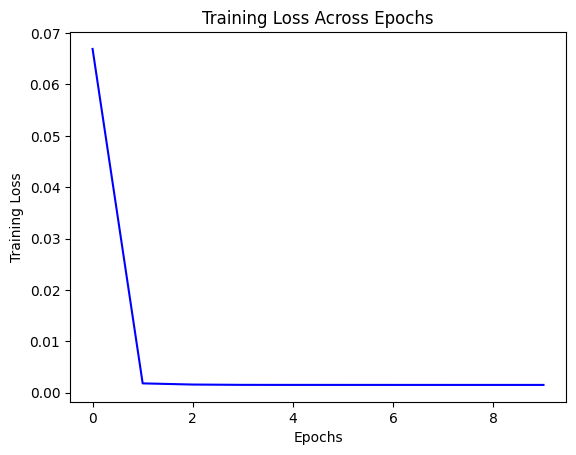

In [ ]:
#just for debugging purposes - students dont have to plot training loss for this question
plt.plot((range(0,num_epochs)), training_losses, color='b')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Epochs")
plt.show()

Evaluate the model on the validation data. Use a threshold of 0.5 to compute the binary predictions (**5 points**).

In [ ]:
######## CODE ##########
# Evaluate model
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(np.float32)
        all_preds.append(preds)
        all_probs.append(probs)
        all_labels.append(y_batch.numpy())

binary_predictions_onehot = np.vstack(all_preds)
probabilities_onehot = np.vstack(all_probs)
true_labels = np.vstack(all_labels)

######## CODE ##########

Compute Precision, Recall, and F1-Score as you did above. Comment on the values and compare performances of the MLP trained on one-hot encodings vs. MLP trained on ESM2 embeddings, and explain potential reasons for differences in performance (**2.5 points**). In your answer, make sure to comment on potential issues with one-hot encodings as well as on the information content of ESM2 embeddings (**2.5 points**).

In [ ]:
######## CODE ##########
# Print precision, recall and f1
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, binary_predictions_onehot, average='micro', zero_division=0
)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

######## CODE ##########

Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000


**The one-hot MLP achieves Precision Recall and F1 of 0 (it predicts no positive GO terms at all under the 0.5 threshold). This contrasts sharply with ESM2 MPL which achieved slightly higher Precision Recall scores. The one-hot model has failed to learn meaningful assocations between sequence composition and GO term labels.**

**One-hot encoding treats all 20 AA as equally dissimilar so there is no notion of biochemical similarity. Two proteins with identical AA composition but completely different sequences and functions would be indistinguishable to this model.**

**ESM2 was pretrained on protein sequences via masked language modeling, learning to predict masked residues from their context. This forces the model to encode evolutionary, strutural, and functional patterns implicitly. ESM2 embeddings effectively transfer hundreds of millions of sequences worth of evolutionary knowledge into a dense representation, giving the downstream MLP a much richer signal to learn from.**


# Problem 2 <font color="blue">(5 points)</font>: Investigating a protein of interest: Mouse hypothalamic galanin-like neuropeptide (GALP_MOUSE)

Compare the GO terms predicted by the MLP and the naive approach for `GALP_MOUSE` in the validation set and its experimental annotations. Note that you can ignore the '`|IEA, `' and '`|IDA`' suffixes in the GO terms. These relate to how the annotations were made - more details can be found [here](http://geneontology.org/GO_REF/0000028.html). Use this [link](https://www.ebi.ac.uk/QuickGO/) to look up the GO terms.


**Experimental Annotations:** GINS complex, regulation of appetite, behavioral response to starvation

**Naive Annotations:** cytosol, metal ion binding, membrane, nucleus, cytoplasm

**ESM2 Annotations:** neuropeptide signaling pathway, extracellular region, hormone activity, adenylate cyclase-activating GPCR signaling pathway


GALP_MOUSE is a hypothalamic neuropeptide known to regulate feeding behavior and energy homeostasis. The experimental annotations reflect this biology since regulation of appetite and behavioral response to starvation are related to this type of activity.

The ESM2 MLP predictions are biologically meaningful . Neuropeptide signaling pathway, hormone activity, and adenylate cyclase-activating GPCR signaling pathway are all consistent with what GALP actually does. While none of the ESM2 predictions exactly match the experimental annotations, they basically capture the correct biological context which suggests that the model has learned meaningful functional representations from sequence alone.

The naive one-hot MLP predictions are generic, high-frequency GO terms that appear across many proteins and carry little specificity.

This shows the advantage of ESM2 embeddings since they encode evolutionary and structural context learned from protein sequences.


In [ ]:
######## CODE ##########
# Experimental annotations
galp = sampled_valid_data[sampled_valid_data['proteins'] == 'GALP_MOUSE'].iloc[0]
exp_annotations = set(galp['exp_annotations'])
print("Experimental annotations:")
for t in exp_annotations:
    print(f"  {t}")

######## CODE ##########

Experimental annotations:
  GO:0032098
  GO:0005102
  GO:0042595


In [ ]:
######## CODE ##########
# MLP trained on one hot encoded sequences (Naive predictions)
galp_idx = sampled_valid_data[sampled_valid_data['proteins'] == 'GALP_MOUSE'].index[0]
valid_pos = sampled_valid_data.index.get_loc(galp_idx)

galp_probs_onehot = probabilities_onehot[valid_pos]
top5_onehot = np.argsort(-galp_probs_onehot)[:5]
naive_predicted = set(mlb.classes_[idx] for idx in top5_onehot)
print("\nNaive (one-hot MLP) top-5 predicted GO terms:")
for t in naive_predicted:
    print(f"  {t}")

######## CODE ##########


Naive (one-hot MLP) top-5 predicted GO terms:
  GO:0005829|IDA
  GO:0016021|IEA
  GO:0005737|IDA
  GO:0046872|IEA
  GO:0005634|IDA


In [ ]:
######## CODE ##########
# MLP trained on ESM2 embeddings (Model predictions)
mlp_predicted = set(galp['top_5_predicted_go_terms'])
print("\nESM2 MLP top-5 predicted GO terms:")
for t in mlp_predicted:
    print(f"  {t}")

print("\nESM2 MLP correct predictions:  ", mlp_predicted & exp_annotations)
print("Naive one-hot correct predictions:", naive_predicted & exp_annotations)

######## CODE ##########


ESM2 MLP top-5 predicted GO terms:
  GO:0005576|IEA
  GO:0007189|IDA
  GO:0007218|IDA
  GO:0007218|IEA
  GO:0005615|IDA

ESM2 MLP correct predictions:   set()
Naive one-hot correct predictions: set()


# Problem 3 <font color="blue">(5 points)</font>: Predicting Protein Structure using ESMFold (5 points)

Use the relevant sequence from the validation dataframe to predict the 3D structure of `GALP_MOUSE` using [ESMFold](https://esmatlas.com/resources?action=fold).  

Paste the relevant protein sequence and hit **"Fold Sequence"**.  

Please upload below a screenshot of the top predicted structure using the **Files** tab to the left.  

Include the sequence you pasted into ESMFold in your answer below and comment on the confidence of the top prediction.  

In [ ]:
##### CODE #######
# you sequence
galp_seq = sampled_valid_data[sampled_valid_data['proteins'] == 'GALP_MOUSE']['sequences'].iloc[0]
print(galp_seq)
##### CODE #######

MACSVHLVLFLTILLSLAETPESAPAHRGRGGWTLNSAGYLLGPVLPVSSKADQGRKRDSALEILDLWKIIDGLPYSHSPRMTKRTMGETFVKANTGDMHILDKNVPKEEATLDSES


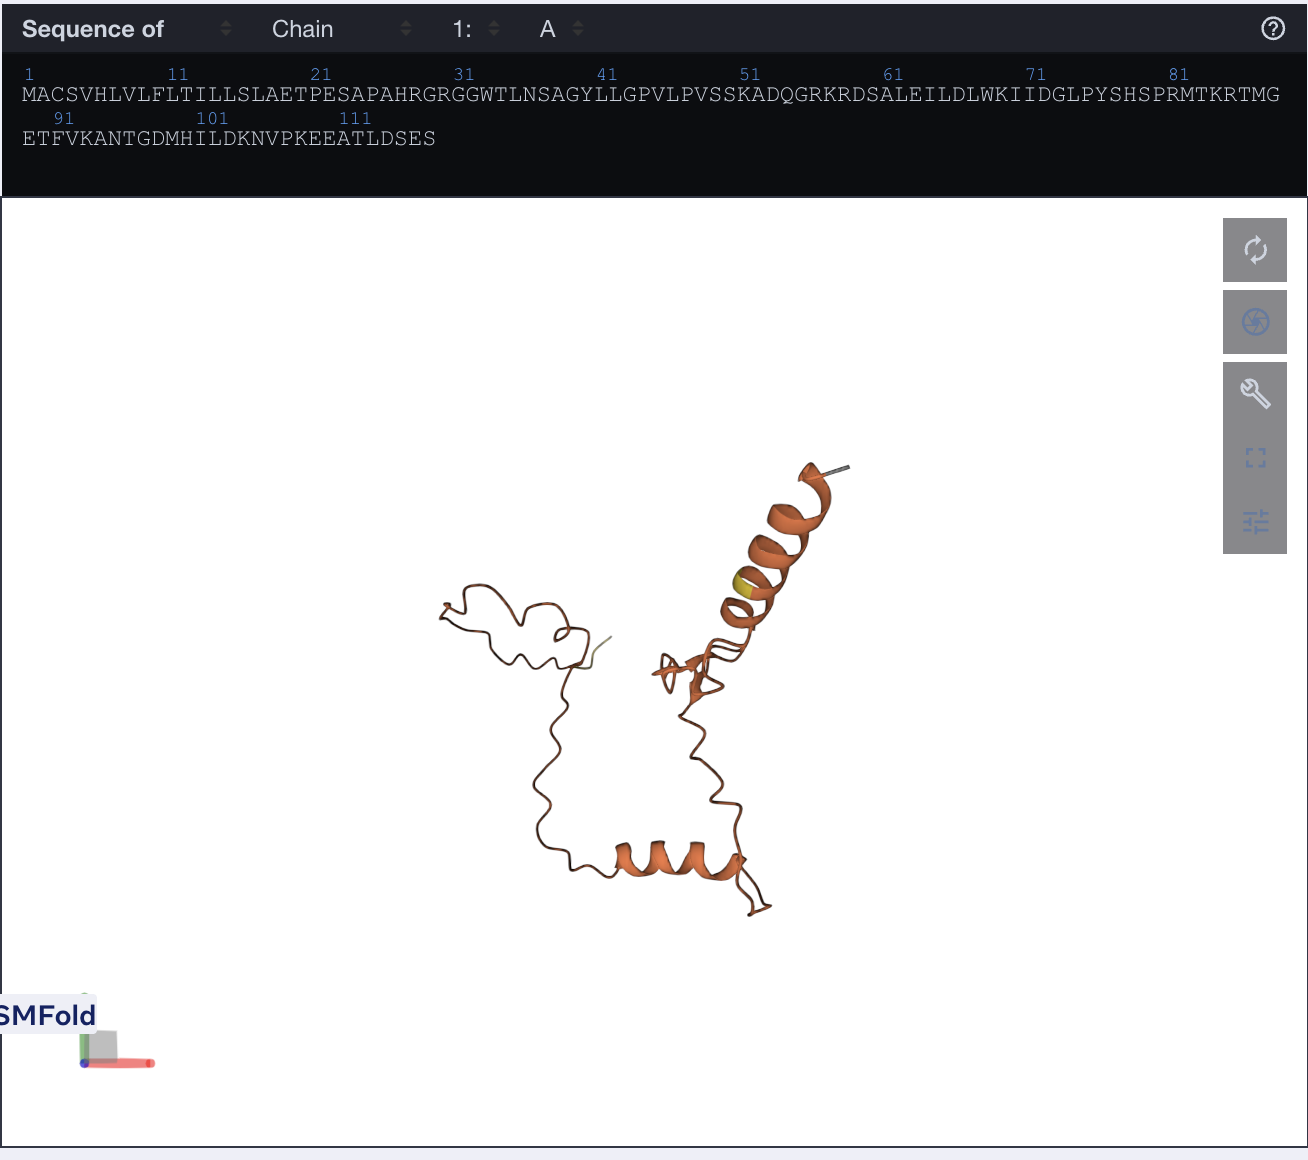



**The predicted structure shows overwhelmingly low confidence throughout. The color scheme in the ESMFold legend runs from blue (high confidence) to red (low confidence), and the structure is almost entirely orange/red, with only a small patch of yellow-green near the helical region, indicating pLDDT scores mostly below 50.**

In [ ]:
import io
import os
import base64
import nbformat
import sys
import time
from PIL import Image
from IPython.display import display, Javascript, HTML

# --- Configuration ---
NOTEBOOK_NAME = "7.C01_PSET6.ipynb" # The name of your file
OUTPUT_FILENAME = "pset_6m_bio_submission.ipynb"
TAG_TO_REMOVE = "background"
MAX_IMG_WIDTH = 800
# Standard locations where Colab saves notebooks.
# IF YOU CHANGE THE LOCATION OF YOUR NOTEBOOK PLEASE ADD THE PATH HERE.
COLAB_PATHS = [
    f"/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}",
    f"/content/drive/MyDrive/{NOTEBOOK_NAME}"
]
# ---------------------

def get_input_path():
    """Determines the path of the notebook based on the environment."""
    if 'google.colab' in sys.modules:
        from google.colab import drive
        # 1. Mount Drive
        if not os.path.exists('/content/drive'):
            print("Mounting Google Drive to access the notebook file...")
            drive.mount('/content/drive')

        for path in COLAB_PATHS:
            if os.path.exists(path):
                return path

        # Fallback if not found
        print(f"\nERROR: Could not find '{NOTEBOOK_NAME}' in your Google Drive.")
        print("Please ensure the file is saved in 'My Drive' or 'Colab Notebooks'.")
        return None

    else:
        # Local Jupyter (runs in current directory)
        return NOTEBOOK_NAME

def resize_base64_image(b64_str, mime_type):
    # (Same resize logic as before - keeping it brief for readability)
    try:
        img_data = base64.b64decode(b64_str)
        img = Image.open(io.BytesIO(img_data))
        if img.width > MAX_IMG_WIDTH:
            ratio = MAX_IMG_WIDTH / img.width
            new_height = int(img.height * ratio)
            img = img.resize((MAX_IMG_WIDTH, new_height), Image.Resampling.LANCZOS)
            buf = io.BytesIO()
            fmt = 'PNG' if 'png' in mime_type else 'JPEG'
            img.save(buf, format=fmt, optimize=True)
            return base64.b64encode(buf.getvalue()).decode('utf-8')
        return b64_str
    except Exception as e:
        return b64_str

def generate_submission():
    # Trigger a save in the browser
    display(Javascript('IPython.notebook.save_checkpoint();'))
    time.sleep(5)

    input_path = get_input_path()
    if not input_path:
        return

    print(f"Reading notebook from: {input_path}")

    try:
        with open(input_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    new_cells = []

    # Filter Cells & Process Images
    for cell in nb.cells:
        tags = cell.get('metadata', {}).get('tags', [])
        tags = [t.lower() for t in tags] if tags else []
        if TAG_TO_REMOVE in tags:
            continue

        if 'outputs' in cell:
            for output in cell['outputs']:
                data = output.get('data', {})
                for mime_type in ['image/png', 'image/jpeg']:
                    if mime_type in data:
                        data[mime_type] = resize_base64_image(data[mime_type], mime_type)
        new_cells.append(cell)

    nb.cells = new_cells

    with open(OUTPUT_FILENAME, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)

    # Download logic for Colab
    if 'google.colab' in sys.modules:
        from google.colab import files
        print(f"Downloading {OUTPUT_FILENAME}...")
        files.download(OUTPUT_FILENAME)
        print(f"Success! {OUTPUT_FILENAME} downloaded.")
    else:
        print(f"Success! {OUTPUT_FILENAME} created.")
        display(HTML(f'<br/><a href="{OUTPUT_FILENAME}" download><b>Click here to download {OUTPUT_FILENAME}</b></a>'))

generate_submission()

<IPython.core.display.Javascript object>

Mounting Google Drive to access the notebook file...
Mounted at /content/drive
Reading notebook from: /content/drive/MyDrive/Colab Notebooks/7.C01_PSET6.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! pset_6m_bio_submission.ipynb downloaded.
